# Simulaciones con medias estocásticas de varias simulaciones

In [188]:
### PARÁMETROS PARA HACER LOS PLOTS, CAMBIAR CADA VEZ #########

simulaciones = 50   #Número total de simulaciones
T_Total = 1000      #Número total de pasos
media = 10          #Cada cuantos pasos hace media
memoria = 4         #Memoria del demonio


In [189]:
### LIBRERÍAS NECESARIAS ##############

import os
import numpy as np
import matplotlib.pyplot as plt

In [180]:
### FUNCIONES PARA TOdO #############

#Pongo la caperta de plots
carpeta_plots = "plots"
os.makedirs(carpeta_plots, exist_ok=True)


def leer_txt(nombre_archivo):
    """
    Lee un archivo .txt situado en la misma carpeta que el notebook.

    Sirve tanto para archivos con una columna como con dos columnas.
    Devuelve siempre un array 2D:
        - shape = (N, 1) si hay una columna
        - shape = (N, 2) si hay dos columnas
    """
    datos = np.loadtxt(nombre_archivo)

    if datos.ndim == 1:
        datos = datos.reshape(-1, 1)

    return datos


def media_por_bloques(datos, media):
    """
    Agrupa los datos en bloques de tamaño 'media' y calcula la media de cada bloque.

    Ejemplo:
        media = 5

        filas 0,1,2,3,4       -> primer punto ploteado
        filas 5,6,7,8,9       -> segundo punto ploteado
        filas 10,11,12,13,14  -> tercer punto ploteado

    Si al final sobran filas y no completan un bloque entero, se descartan.
    """
    if media <= 0:
        raise ValueError("La variable 'media' debe ser mayor que cero.")

    num_filas = datos.shape[0]
    num_bloques = num_filas // media

    if num_bloques == 0:
        raise ValueError(
            f"El archivo tiene {num_filas} filas, pero media = {media}. "
            "No hay suficientes datos para hacer ni un bloque."
        )

    # Recorto para quedarme solo con bloques completos
    datos_recortados = datos[:num_bloques * media]

    # Forma:
    # (num_bloques, media, num_columnas)
    datos_bloques = datos_recortados.reshape(num_bloques, media, datos.shape[1])

    # Media dentro de cada bloque temporal
    datos_promediados = datos_bloques.mean(axis=1)

    return datos_promediados


def eje_temporal_promediado(num_bloques, media):
    """
    Eje temporal asociado a los bloques promediados.

    Para media = 5:
        primer punto representa los pasos 0-4
        segundo punto representa los pasos 5-9
        etc.

    Uso el centro del bloque:
        2, 7, 12, ...
    """
    return (np.arange(num_bloques) * media) + (media - 1) / 2


def plot_evolucion(nombre_archivo, titulo, ylabel, nombre_guardado, etiquetas=None):
    """
    Lee un txt, promedia cada 'media' pasos temporales,
    representa todas sus columnas frente al tiempo
    y guarda la figura en la carpeta plots.
    """
    datos = leer_txt(nombre_archivo)

    # Aquí está la parte importante:
    # no se plotea cada fila directamente, sino la media de cada bloque de 'media' filas.
    datos_promediados = media_por_bloques(datos, media)

    t = eje_temporal_promediado(len(datos_promediados), media)

    plt.figure(figsize=(8, 5))

    for col in range(datos_promediados.shape[1]):
        if etiquetas is not None and col < len(etiquetas):
            label = etiquetas[col]
        else:
            label = f"Columna {col + 1}"

        plt.plot(t, datos_promediados[:, col], label=label, linewidth=2)

    plt.xlabel("Tiempo")
    plt.ylabel(ylabel)
    plt.title(f"{titulo} media cada {media} pasos en {simulaciones} simulaciones, M={memoria}")
    plt.grid(True, alpha=0.3)

    if datos_promediados.shape[1] > 1:
        plt.legend()

    plt.tight_layout()

    ruta_guardado = os.path.join(carpeta_plots, nombre_guardado)
    plt.savefig(ruta_guardado, dpi=300)
    plt.show()

    print(f"Plot guardado en: {ruta_guardado}")

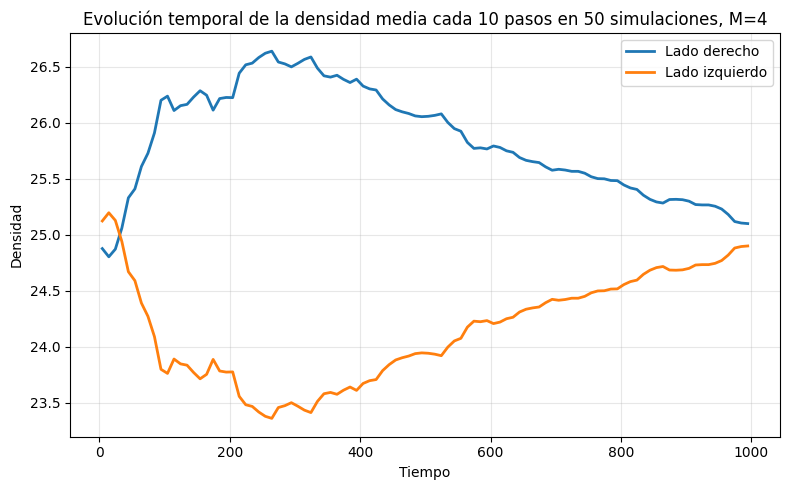

Plot guardado en: plots\evolucion_densidad.png


In [181]:
### EVOLUCIÓN DENSIDAD TOTAL ##############

plot_evolucion(
    nombre_archivo="Ave_Density.txt",
    titulo="Evolución temporal de la densidad",
    ylabel="Densidad",
    nombre_guardado="evolucion_densidad.png",
    etiquetas=["Lado derecho", "Lado izquierdo"]
)

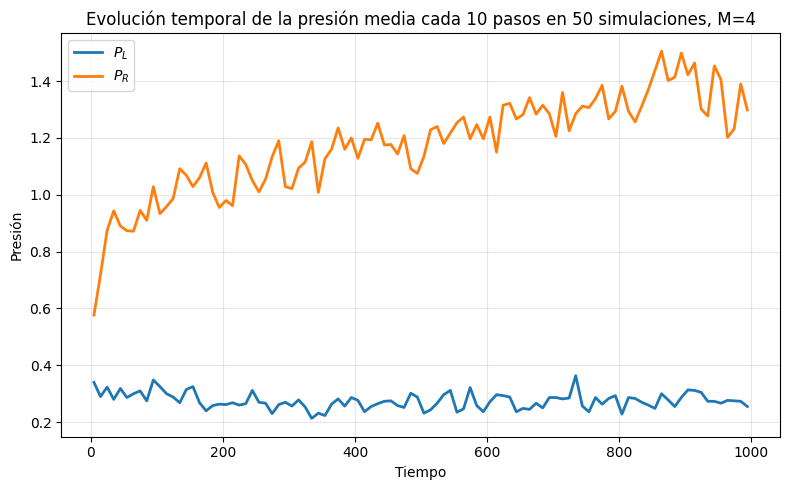

Plot guardado en: plots\evolucion_presion.png


In [182]:
### EVOLUCIÓN PRESIÓN SOBRE MURO ##############

plot_evolucion(
    nombre_archivo="Ave_Presion.txt",
    titulo="Evolución temporal de la presión",
    ylabel="Presión",
    nombre_guardado="evolucion_presion.png",
    etiquetas=[r"$P_L$", r"$P_R$"]
)

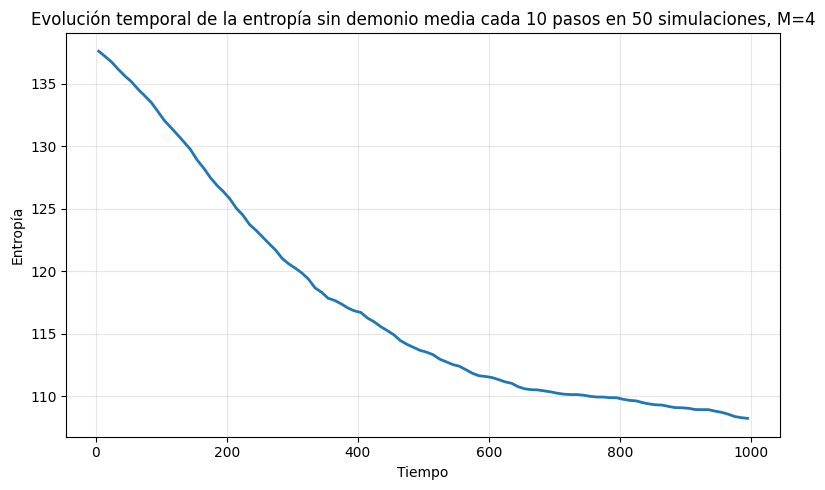

Plot guardado en: plots\evolucion_entropia_sin_demonio.png


In [183]:
### EVOLUCIÓN ENTROPÍA SIN DEMONIO ##########

plot_evolucion(
    nombre_archivo="Ave_Entropy.txt",
    titulo="Evolución temporal de la entropía sin demonio",
    ylabel="Entropía",
    nombre_guardado="evolucion_entropia_sin_demonio.png"
)

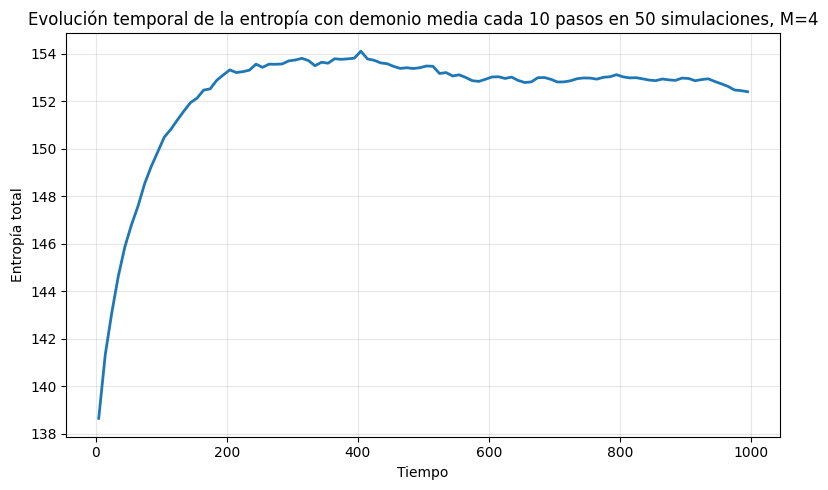

Plot guardado en: plots\evolucion_entropia_con_demonio.png


In [184]:
### EVOLUCIÓN ENTROPÍA + CALOR DEMONIO ###########
plot_evolucion(
    nombre_archivo="Ave_Demon_and_Entropy.txt",
    titulo="Evolución temporal de la entropía con demonio",
    ylabel="Entropía total",
    nombre_guardado="evolucion_entropia_con_demonio.png"
)

## Simulaciones con errores

In [193]:
### FUNCIONES NECESARIAS #################

def leer_txt(nombre_archivo):
    datos = np.loadtxt(nombre_archivo)

    if datos.ndim == 1:
        datos = datos.reshape(-1, 1)

    return datos


def plot_evolucion_con_error(nombre_archivo_media, nombre_archivo_error,
                             titulo, ylabel, nombre_guardado, etiquetas=None):

    datos_media = leer_txt(nombre_archivo_media)
    datos_error = leer_txt(nombre_archivo_error)

    if datos_media.shape != datos_error.shape:
        raise ValueError(
            f"Las dimensiones no coinciden entre {nombre_archivo_media} y {nombre_archivo_error}: "
            f"{datos_media.shape} vs {datos_error.shape}"
        )

    t = np.arange(datos_media.shape[0])

    plt.figure(figsize=(8, 5))

    for col in range(datos_media.shape[1]):
        y = datos_media[:, col]
        err = datos_error[:, col]

        if etiquetas is not None and col < len(etiquetas):
            label = etiquetas[col]
        else:
            label = f"Curva {col + 1}"

        linea_central, = plt.plot(t, y, linewidth=2, label=label)
        color = linea_central.get_color()

        plt.plot(t, y + err, color=color, alpha=0.35, linewidth=1.5)
        plt.plot(t, y - err, color=color, alpha=0.35, linewidth=1.5)

    plt.xlabel("Paso temporal")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    ruta_guardado = os.path.join(carpeta_plots, nombre_guardado)
    plt.savefig(ruta_guardado, dpi=300)
    plt.show()

    print(f"Plot guardado en: {ruta_guardado}")

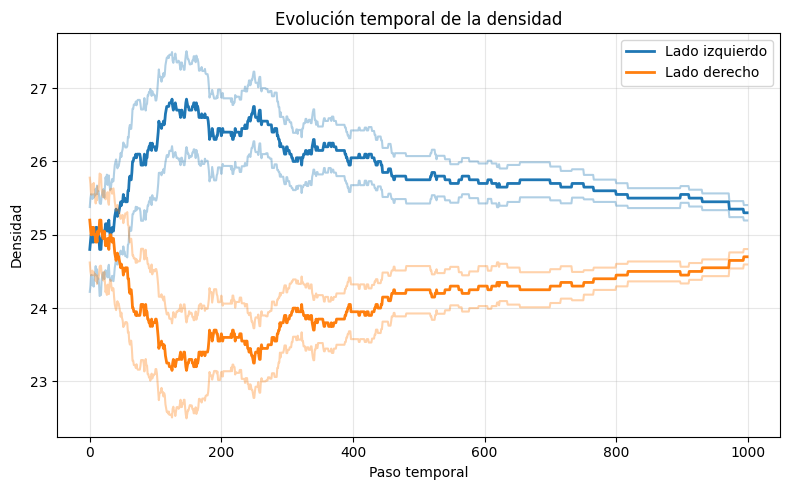

Plot guardado en: plots\evolucion_densidad_con_error.png


In [197]:
### DENSIDAD CON ERRORES #######
plot_evolucion_con_error(
    nombre_archivo_media="Ave_Density.txt",
    nombre_archivo_error="Error_Densidad.txt",
    titulo="Evolución temporal de la densidad",
    ylabel="Densidad",
    nombre_guardado="evolucion_densidad_con_error.png",
    etiquetas=["Lado izquierdo", "Lado derecho"]
)

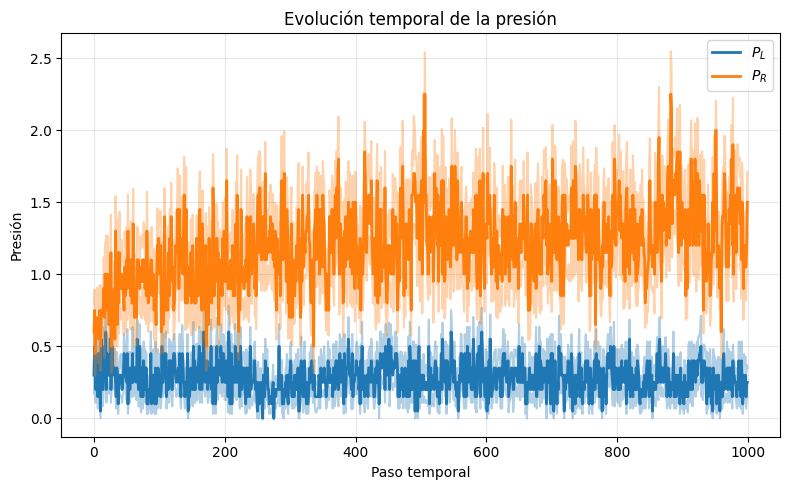

Plot guardado en: plots\evolucion_presion_con_error.png


In [198]:
### PRESIÓN CON ERRORES ###########

plot_evolucion_con_error(
    nombre_archivo_media="Ave_Presion.txt",
    nombre_archivo_error="Error_Presion.txt",
    titulo="Evolución temporal de la presión",
    ylabel="Presión",
    nombre_guardado="evolucion_presion_con_error.png",
    etiquetas=[r"$P_L$", r"$P_R$"]
)

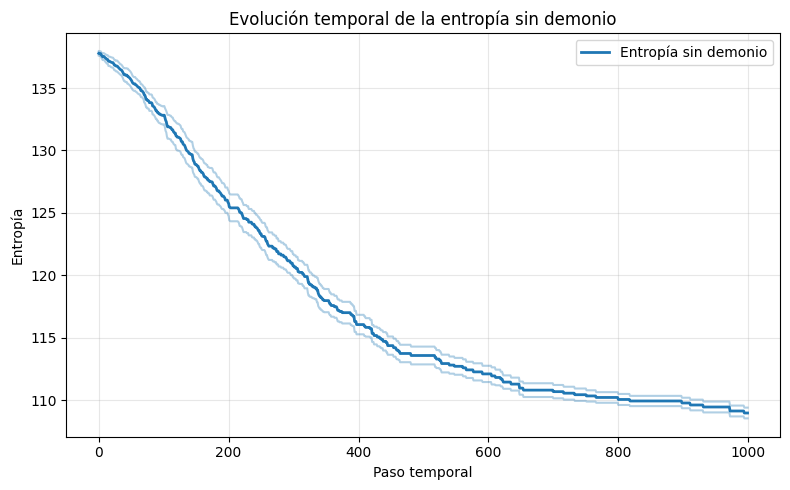

Plot guardado en: plots\evolucion_entropia_sin_demonio_con_error.png


In [200]:
### ENTROPÍA DEL SISTEMA CON ERRORES ###############
plot_evolucion_con_error(
    nombre_archivo_media="Ave_Entropy.txt",
    nombre_archivo_error="Error_Entropia.txt",
    titulo="Evolución temporal de la entropía sin demonio",
    ylabel="Entropía",
    nombre_guardado="evolucion_entropia_sin_demonio_con_error.png",
    etiquetas=["Entropía sin demonio"]
)

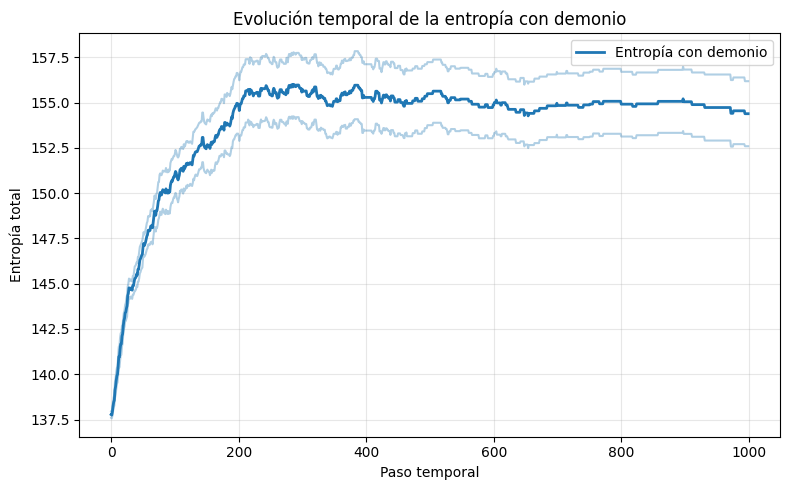

Plot guardado en: plots\evolucion_entropia_con_demonio_con_error.png


In [202]:
### ENTROPÍA + DEMONIO CON ERRORES #################
plot_evolucion_con_error(
    nombre_archivo_media="Ave_Demon_and_Entropy.txt",
    nombre_archivo_error="Error_Entropia_Demonio.txt",
    titulo="Evolución temporal de la entropía con demonio",
    ylabel="Entropía total",
    nombre_guardado="evolucion_entropia_con_demonio_con_error.png",
    etiquetas=["Entropía con demonio"]
)